In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

plt.style.use("default")

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_DIR = "data_2026_A2/data"


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


train_task1 = load_json(
    f"{DATA_DIR}/training_set_task1.txt"
)

dev_task1 = load_json(
    f"{DATA_DIR}/dev_set_task1.txt"
)

test_task1 = load_json(
    f"{DATA_DIR}/test_set_task1.txt"
)


train_task2 = load_json(
    f"{DATA_DIR}/training_set_task2.txt"
)

dev_task2 = load_json(
    f"{DATA_DIR}/dev_set_task2.txt"
)

test_task2 = load_json(
    f"{DATA_DIR}/test_set_task2.txt"
)


print("Task 1")
print("Train:", len(train_task1))
print("Dev:", len(dev_task1))
print("Test:", len(test_task1))


print("\nTask 2")
print("Train:", len(train_task2))
print("Dev:", len(dev_task2))
print("Test:", len(test_task2))

Task 1
Train: 688
Dev: 63
Test: 200

Task 2
Train: 688
Dev: 63
Test: 200


## EDA

### EDA for part 1

In [16]:
train_task1_df = pd.DataFrame(
    train_task1
)

display(
    train_task1_df.head()
)

,id,labels,text
0,128,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n
1,189,[],This is not an accident!
2,96,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
3,154,"[Causal Oversimplification, Loaded Language, N...",PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...
4,15,[],WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n


In [17]:
task1_split_summary = pd.DataFrame(
    {
        "Split": [
            "Train",
            "Validation",
            "Test"
        ],

        "Number of memes": [
            len(train_task1),
            len(dev_task1),
            len(test_task1)
        ]
    }
)

display(
    task1_split_summary
)

,Split,Number of memes
0,Train,688
1,Validation,63
2,Test,200


In [18]:
train_task1_df["num_labels"] = (
    train_task1_df["labels"]
    .apply(len)
)

display(
    train_task1_df[
        "num_labels"
    ].describe()
)

count    688.000000
mean       1.720930
std        1.348037
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: num_labels, dtype: float64

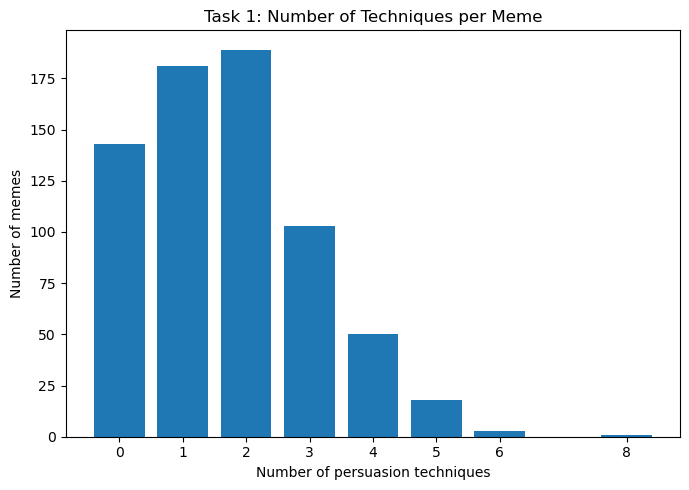

In [19]:
label_count_distribution = (
    train_task1_df[
        "num_labels"
    ]
    .value_counts()
    .sort_index()
)


plt.figure(
    figsize=(7, 5)
)

plt.bar(
    label_count_distribution.index,
    label_count_distribution.values
)

plt.xlabel(
    "Number of persuasion techniques"
)

plt.ylabel(
    "Number of memes"
)

plt.title(
    "Task 1: Number of Techniques per Meme"
)

plt.xticks(
    label_count_distribution.index
)

plt.tight_layout()
plt.show()

In [21]:
task1_label_counter = Counter()

for labels in train_task1_df["labels"]:

    for label in labels:

        task1_label_counter[label] += 1


task1_label_frequency = (
    pd.DataFrame(
        task1_label_counter.items(),
        columns=[
            "Technique",
            "Count"
        ]
    )
    .sort_values(
        "Count",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    task1_label_frequency
)

,Technique,Count
0,Loaded Language,358
1,Name calling/Labeling,218
2,Smears,200
3,Exaggeration/Minimisation,52
4,Doubt,48
5,Slogans,44
6,Appeal to fear/prejudice,43
7,Whataboutism,40
8,Glittering generalities (Virtue),32
9,Causal Oversimplification,27


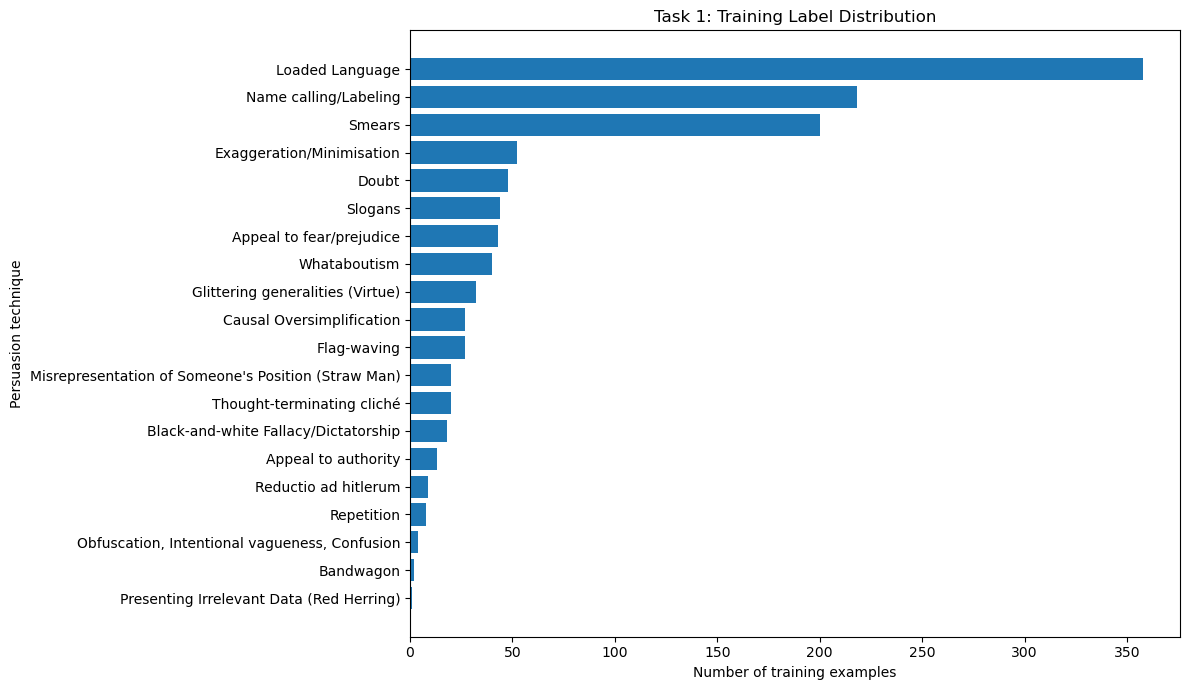

In [22]:
plt.figure(
    figsize=(12, 7)
)

plt.barh(
    task1_label_frequency[
        "Technique"
    ][::-1],

    task1_label_frequency[
        "Count"
    ][::-1]
)

plt.xlabel(
    "Number of training examples"
)

plt.ylabel(
    "Persuasion technique"
)

plt.title(
    "Task 1: Training Label Distribution"
)

plt.tight_layout()
plt.show()

In [23]:
train_task1_df["word_count"] = (
    train_task1_df["text"]
    .apply(
        lambda text:
        len(text.split())
    )
)

train_task1_df["character_count"] = (
    train_task1_df["text"]
    .apply(len)
)


display(
    train_task1_df[
        [
            "word_count",
            "character_count"
        ]
    ].describe()
)

,word_count,character_count
count,688.000000,688.000000
mean,17.962209,103.741279
std,11.572631,67.788071
min,1.000000,5.000000
25%,10.000000,54.000000
50%,15.000000,86.000000
75%,24.000000,142.000000
max,72.000000,427.000000


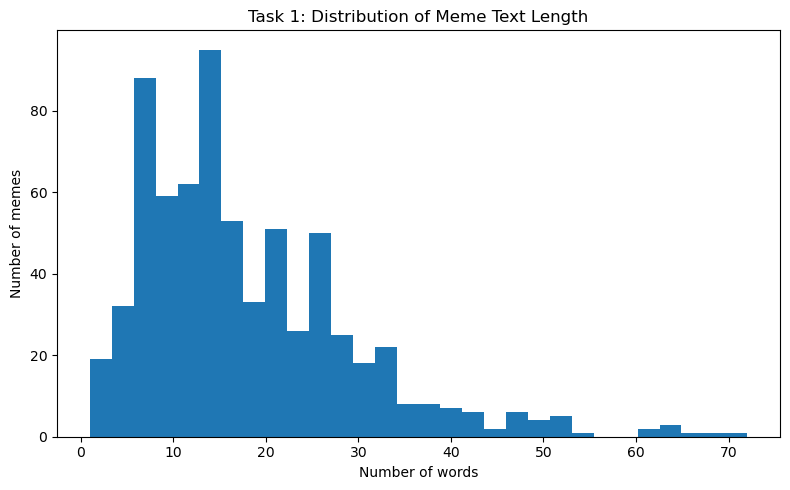

In [24]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    train_task1_df["word_count"],
    bins=30
)

plt.xlabel(
    "Number of words"
)

plt.ylabel(
    "Number of memes"
)

plt.title(
    "Task 1: Distribution of Meme Text Length"
)

plt.tight_layout()
plt.show()

In [25]:
for i in range(3):

    print("=" * 70)

    print(
        "ID:",
        train_task1[i]["id"]
    )

    print(
        "\nText:"
    )

    print(
        train_task1[i]["text"]
    )

    print(
        "\nLabels:"
    )

    print(
        train_task1[i]["labels"]
    )

    print()

ID: 128

Text:
THERE ARE ONLY TWO GENDERS

FEMALE 

MALE


Labels:
['Black-and-white Fallacy/Dictatorship']

ID: 189

Text:
This is not an accident!

Labels:
[]

ID: 96

Text:
SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?

POWER COMES FROM THE BARREL OF A GUN, COMRADES.

WHAT ABOUT THE ONE WHO SHOT CONGRESSMAN SCALISE OR THE DAYTON OHIO MASS SHOOTER?


Labels:
['Loaded Language', 'Name calling/Labeling', 'Slogans', 'Smears']



### Part B — Task 2 EDA

In [26]:
train_task2_df = pd.DataFrame(
    train_task2
)

display(
    train_task2_df.head()
)

,id,text,labels
0,128,THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n,"[{'start': 0, 'end': 41, 'technique': 'Black-a..."
1,189,This is not an accident!,[]
2,96,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...,"[{'end': 83, 'start': 47, 'technique': 'Slogan..."
3,154,PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...,"[{'end': 8, 'start': 0, 'technique': 'Loaded L..."
4,15,WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n,[]


In [27]:
task2_split_summary = pd.DataFrame(
    {
        "Split": [
            "Train",
            "Validation",
            "Test"
        ],

        "Number of memes": [
            len(train_task2),
            len(dev_task2),
            len(test_task2)
        ]
    }
)

display(
    task2_split_summary
)

,Split,Number of memes
0,Train,688
1,Validation,63
2,Test,200


In [28]:
span_annotations = []

for item in train_task2:

    for annotation in item["labels"]:

        span_annotations.append(
            {
                "id":
                    item["id"],

                "technique":
                    annotation[
                        "technique"
                    ],

                "start":
                    annotation[
                        "start"
                    ],

                "end":
                    annotation[
                        "end"
                    ],

                "text_fragment":
                    annotation[
                        "text_fragment"
                    ]
            }
        )


train_spans_df = pd.DataFrame(
    span_annotations
)


display(
    train_spans_df.head()
)

,id,technique,start,end,text_fragment
0,128,Black-and-white Fallacy/Dictatorship,0,41,THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE
1,96,Slogans,47,83,POWER COMES FROM THE BARREL OF A GUN
2,96,Name calling/Labeling,3,14,BERNIE BROS
3,96,Loaded Language,33,41,VIOLENCE
4,96,Loaded Language,163,175,MASS SHOOTER


In [29]:
train_spans_df["span_length"] = (
    train_spans_df["end"]
    -
    train_spans_df["start"]
)


print(
    "Total span annotations:",
    len(train_spans_df)
)

print(
    "Average span length:",
    round(
        train_spans_df[
            "span_length"
        ].mean(),
        2
    ),
    "characters"
)

print(
    "Median span length:",
    train_spans_df[
        "span_length"
    ].median()
)

print(
    "Maximum span length:",
    train_spans_df[
        "span_length"
    ].max()
)

Total span annotations: 1498
Average span length: 39.67 characters
Median span length: 19.0
Maximum span length: 427


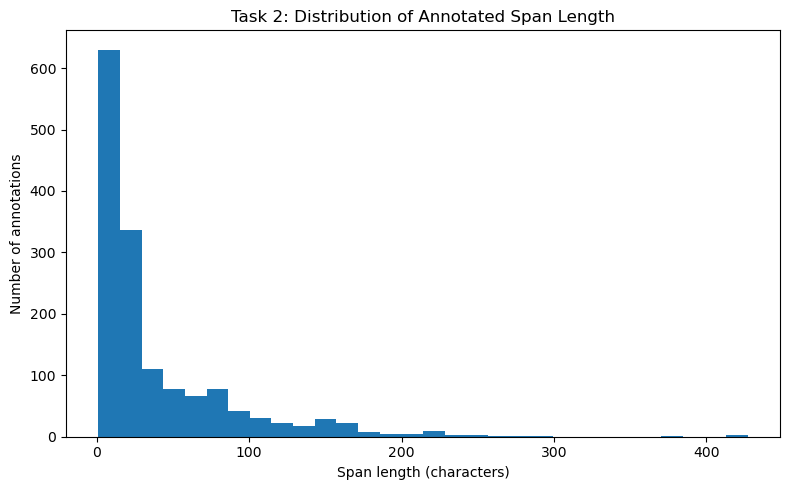

In [30]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    train_spans_df[
        "span_length"
    ],
    bins=30
)

plt.xlabel(
    "Span length (characters)"
)

plt.ylabel(
    "Number of annotations"
)

plt.title(
    "Task 2: Distribution of Annotated Span Length"
)

plt.tight_layout()
plt.show()

In [31]:
overlap_results = []

for item in train_task2:

    labels = item["labels"]

    for i in range(len(labels)):

        for j in range(
            i + 1,
            len(labels)
        ):

            a = labels[i]
            b = labels[j]

            overlap = (
                a["start"] < b["end"]
                and
                b["start"] < a["end"]
            )

            if overlap:

                overlap_results.append(
                    {
                        "id":
                            item["id"],

                        "technique_1":
                            a["technique"],

                        "technique_2":
                            b["technique"],

                        "span_1":
                            a["text_fragment"],

                        "span_2":
                            b["text_fragment"]
                    }
                )


overlap_df = pd.DataFrame(
    overlap_results
)


print(
    "Overlapping annotation pairs:",
    len(overlap_df)
)

display(
    overlap_df.head(10)
)

Overlapping annotation pairs: 1009


,id,technique_1,technique_2,span_1,span_2
0,96,Slogans,Smears,POWER COMES FROM THE BARREL OF A GUN,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
1,96,Name calling/Labeling,Smears,BERNIE BROS,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
2,96,Loaded Language,Smears,VIOLENCE,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
3,96,Loaded Language,Smears,MASS SHOOTER,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
4,96,Loaded Language,Smears,COMRADES,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
5,154,Loaded Language,Name calling/Labeling,PATHETIC,PATHETIC
6,154,Loaded Language,Smears,PATHETIC,PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...
7,154,Name calling/Labeling,Smears,PATHETIC,PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...
8,154,Name calling/Labeling,Loaded Language,Cowardly Asshole,Cowardly Asshole
9,154,Name calling/Labeling,Smears,Cowardly Asshole,PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...


In [32]:
memes_with_overlap = set(
    overlap_df["id"]
)

overlap_summary = pd.DataFrame(
    {
        "Category": [
            "No overlapping spans",
            "At least one overlapping span"
        ],

        "Number of memes": [
            len(train_task2)
            -
            len(memes_with_overlap),

            len(memes_with_overlap)
        ]
    }
)


display(
    overlap_summary
)

,Category,Number of memes
0,No overlapping spans,351
1,At least one overlapping span,337


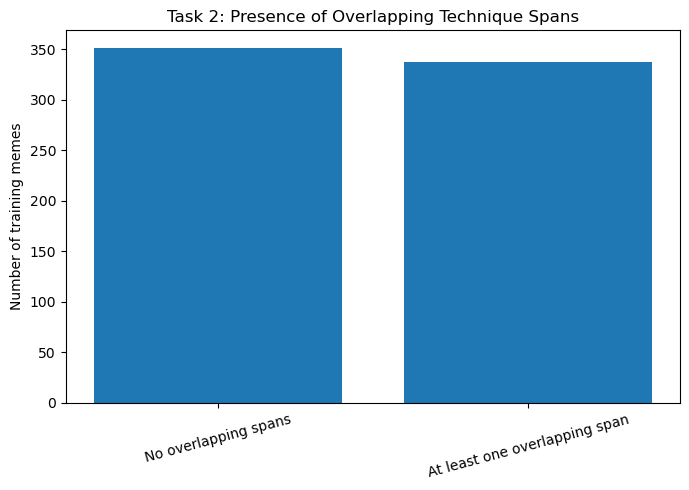

In [33]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    overlap_summary["Category"],
    overlap_summary["Number of memes"]
)

plt.ylabel(
    "Number of training memes"
)

plt.title(
    "Task 2: Presence of Overlapping Technique Spans"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()